In [2]:
# Run this cell to mount your Google Drive.
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [3]:
## this is to install and import pydrive utilities to help us download our data to colab from google drive
!pip install -U -q PyDrive

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

In [4]:
# this is form authentication of user
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [5]:
## we are downloading file from Google drive to our colab environment
## this is just a empty folder to put our segmentation mask results

file_id = '1EaWui3uYpgfa1mEReU8jtO9WOG4U3TEw'          ## at the end of google drive shareble link
downloaded_0 = drive.CreateFile({'id': file_id})
downloaded_0.GetContentFile('segmented.zip')
!unzip segmented.zip # unzipping the zipped file

Archive:  segmented.zip
   creating: segmented/


In [7]:
# # out dataset downloaded
# # this folder have train and test data

file_id = '1AdCCS347-qmPKIaMPk4SHCU4PRoP12TR'          ## at the end of google drive shareble link
downloaded_1 = drive.CreateFile({'id': file_id})
downloaded_1.GetContentFile('Hc_calculation.zip')
!unzip Hc_calculation.zip
print('Dataset Loaded')

Archive:  Hc_calculation.zip
replace Hc_calculation/test_set/000_HC.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset Loaded


In [9]:
import cv2
import os
import matplotlib.pyplot as plt
import pandas as pd

# **Mask Generation**
Done only once and replaced that  annotation with masks permanently
Did not changed the annotation file name though

## **Warning!!!**
Do not run below cells as task is already completed

In [10]:
train_pixel_file = pd.read_csv('/content/Hc_calculation/training_set_pixel_size_and_HC.csv')
train_pixel_file.head()
# This Dataframe will be used to extract image names hence by doing image_name + '_Annotation' we will get annotation names

,filename,pixel size(mm),head circumference (mm)
0,000_HC.png,0.069136,44.30
1,001_HC.png,0.089659,56.81
2,002_HC.png,0.062033,68.75
3,003_HC.png,0.091291,69.00
4,004_HC.png,0.061240,59.81


In [11]:
# This function takes annotation and spits out corresponding mask
def masking(image):
    imgray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(imgray, 127, 255, 0)
    useless0,contours, useless1 = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    ellipse = cv2.fitEllipse(contours[0])
    return cv2.ellipse(image, ellipse, (255,255,255), -1)

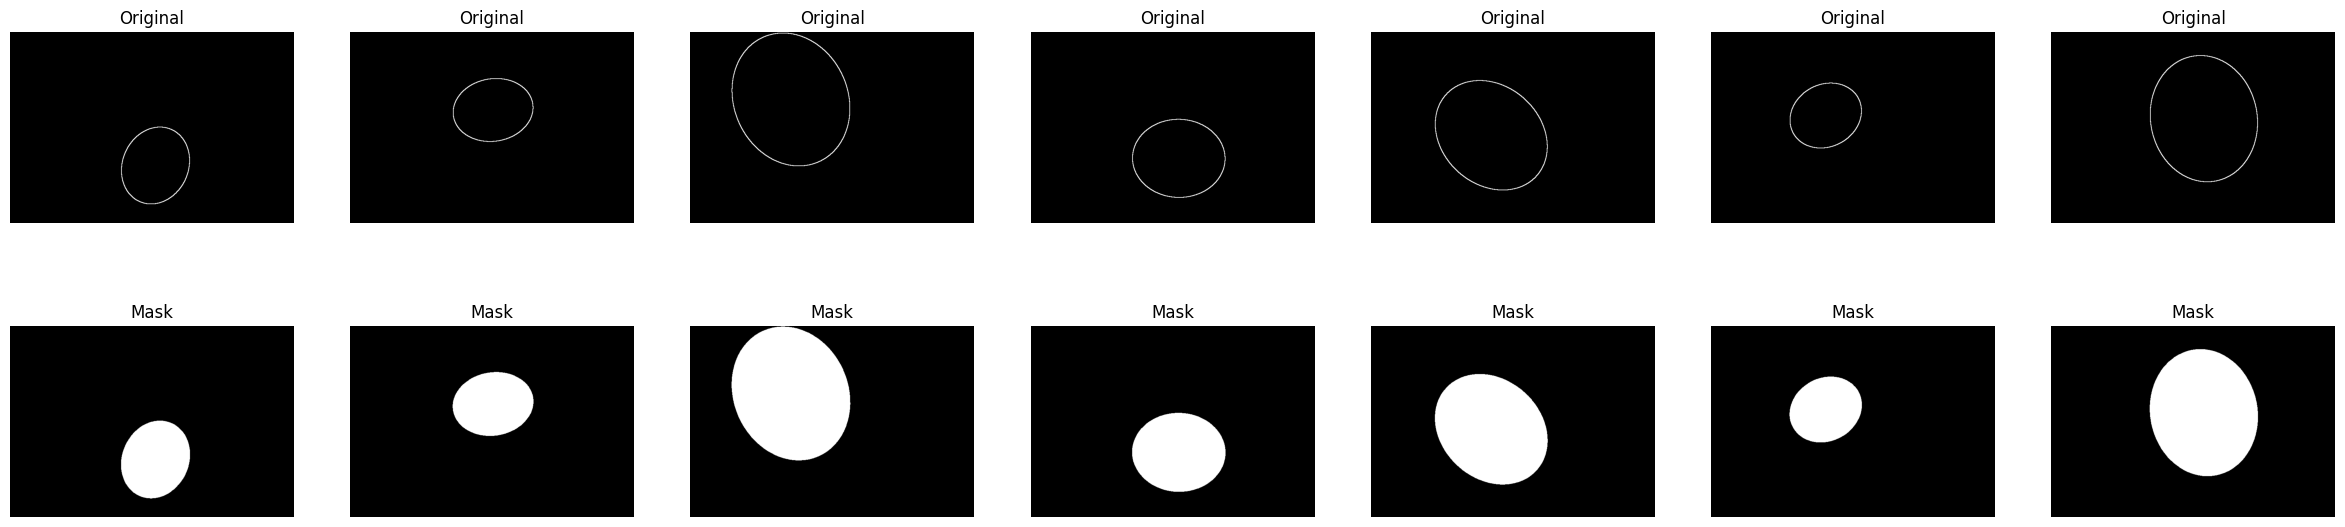

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd



def masking(image):
    imgray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Create a mask with the same dimensions as the input image, initialized to zero (black)
    mask = np.zeros_like(image)

    if contours:  # Ensure there is at least one contour
        if len(contours[0]) >= 5:  # Fit an ellipse if there are enough points
            ellipse = cv2.fitEllipse(contours[0])
            cv2.ellipse(mask, ellipse, (255, 255, 255), -1)  # Draw the ellipse on the mask

    return mask

fig = plt.figure(figsize=(30, 7))



for index in range(7):
    file_path = os.path.join('/content/Hc_calculation/training_set', train_pixel_file.iloc[index, 0].replace('.png', '_Annotation.png'))
    image = cv2.imread(file_path)

    if image is not None:
        ax = fig.add_subplot(2, 7, index + 1)  # Annotated plot
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.title.set_text('Original')
        ax.axis('off')

        ax = fig.add_subplot(2, 7, index + 8)  # Mask plot
        ax.imshow(masking(image))
        ax.title.set_text('Mask')
        ax.axis('off')
    else:
        print(f"Image at {file_path} could not be loaded.")

plt.show()


In [26]:

for index in range(len(train_pixel_file)):
    file_path = os.path.join('/content/Hc_calculation/training_set', train_pixel_file.iloc[index, 0].replace('.png','_Annotation.png'))
    image = cv2.imread(file_path)
    mask = masking(image)
    cv2.imwrite(file_path, mask)

## **Warning!!!**
**Done with mask generation. Don't run above cells ever again**

### **Do all the imports in below cell**

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from skimage import io, color
from PIL import Image
import cv2

import os
import random

import torch
from torch.utils.data  import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
import torch.nn as nn
import torch.nn.functional as F
import torchvision

In [28]:
validation_set_size = 0.20           

In [29]:
# our dataset class
class HC18(Dataset):
  #""" train and validation dataset class"""
    def __init__(self, root_dir, train = True, transformX = None, transformY = None):
        self.pixel_file = pd.read_csv(os.path.join(root_dir, 'training_set_pixel_size_and_HC.csv'))
        self.root_dir = root_dir
        self.transformX = transformX
        self.transformY = transformY
        self.train = train

        # lets split the dataset in train and validation
        self.train_data, self.validation_data = train_test_split(self.pixel_file, test_size = validation_set_size, random_state = 5)

    def __len__(self):

        if self.train:
          length = len(self.train_data)
        else:
          length = len(self.validation_data)
        return length

    def __getitem__(self, index):

        if self.train:
          imx_name = os.path.join(self.root_dir, 'training_set', self.train_data.iloc[index, 0])
          imy_name = os.path.join(self.root_dir, 'training_set',self.train_data.iloc[index, 0].replace('.png','_Annotation.png'))

        else:
          imx_name = os.path.join(self.root_dir, 'training_set', self.validation_data.iloc[index, 0])
          imy_name = os.path.join(self.root_dir, 'training_set',self.validation_data.iloc[index, 0].replace('.png','_Annotation.png'))


        imx = Image.open(imx_name)
        imy = Image.open(imy_name).convert('L')

        ## tried some data augmentation techniques
        if self.train:
          # Random horizontal flipping
          if random.random() > 0.5:
              imx = TF.hflip(imx)
              imy = TF.hflip(imy)

          # Random vertical flipping
          if random.random() > 0.5:
              imx = TF.vflip(imx)
              imy = TF.vflip(imy)


          # Random rotation
          if random.random() > 0.8:
            angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
            imx = TF.rotate(imx, angle)
            imy = TF.rotate(imy, angle)






        if self.transformX :
            imx = self.transformX(imx)
            imy = self.transformY(imy)

        sample = {'image': imx, 'annotation': imy}
        return sample

In [31]:
# our datasets
tx_X = transforms.Compose([ transforms.Resize((572, 572)),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5,), (0.5,))
                              ])
tx_Y = transforms.Compose([ transforms.Resize((572, 572)),
                              transforms.ToTensor(), 
                              ])
train_data = HC18('/content/Hc_calculation', train = True, transformX = tx_X, transformY = tx_Y)
validation_data = HC18('/content/Hc_calculation', train = False, transformX = tx_X, transformY = tx_Y )

In [32]:

train_loader = DataLoader(dataset = train_data, batch_size = 2, shuffle = True, num_workers = 2 )
validation_loader = DataLoader(dataset = validation_data, batch_size = 2, shuffle = True, num_workers = 2)

In [33]:
# this function will return numpy array from the transformed tensors which were
# obtained from our train_loader. Just to plot them and see if they are intact :) ha ha
def im_converterX(tensor):
    image = tensor.cpu().clone().detach().numpy() # make copy of tensor and converting it to numpy as we will need original later
    image = image.transpose(1,2,0) # swapping axes making (1, 28, 28) image to a (28, 28, 1)
 # print(image.shape)
    image = image * np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)) # unnormalizing the image # this also outputs (28, 28, 3) which seems important for plt.imshow
    image = image.clip(0, 1) # to make sure final values are in range 0 to 1 as .ToTensor outputed
    return image

In [34]:
# this function will return numpy array from the transformed tensors which were
# obtained from our train_loader
def im_converterY(tensor):
    image = tensor.cpu().clone().detach().numpy() # make copy of tensor and converting it to numpy as we will need original later
    image = image.transpose(1,2,0) # swapping axes making (1, 28, 28) image to a (28, 28, 1)
 # print(image.shape)
    image = image * np.array((1, 1, 1)) 
    image = image.clip(0, 1) # to make sure final values are in range 0 to 1 as .ToTensor outputed
    return image

0 torch.Size([2, 1, 572, 572]) torch.Size([2, 1, 572, 572])


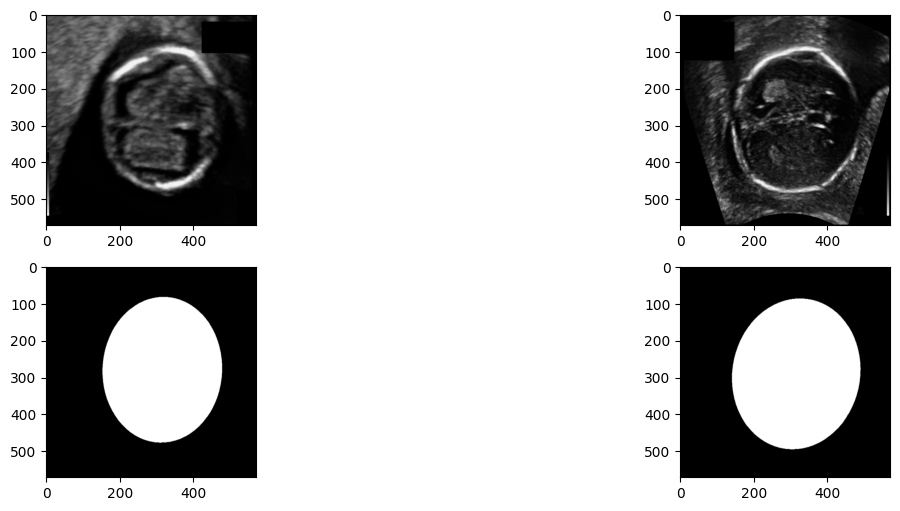

In [35]:
## Here we loop through our train_loader and see the images
## Looks good
fig = plt.figure(figsize = (15,6))
for ith_batch, sample_batched in enumerate(train_loader):
    print(ith_batch, sample_batched['image'].size(), sample_batched['annotation'].size())

    for index in range(2):
        ax = fig.add_subplot(2, 2 , index + 1)  # subplot index starts from 1
        plt.imshow(im_converterX(sample_batched['image'][index]))
        ax = fig.add_subplot(2, 2, index + 3)
        plt.imshow(im_converterY(sample_batched['annotation'][index]))
    break

In [36]:
class double_conv(nn.Module):
    '''(conv => BN => ReLU) * 2'''

    def __init__(self, in_ch, out_ch):
        super(double_conv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            #nn.Dropout2d(0.7),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            #nn.Dropout2d(0.77),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.conv(x)
        return x


class inconv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(inconv, self).__init__()
        self.conv = double_conv(in_ch, out_ch)

    def forward(self, x):
        x = self.conv(x)
        return x


class down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(down, self).__init__()
        self.mpconv = nn.Sequential(
            nn.MaxPool2d(2),
            double_conv(in_ch, out_ch)
        )

    def forward(self, x):
        x = self.mpconv(x)
        return x


class up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super(up, self).__init__()

        if bilinear: #upsampling will not be learnable
            self.up = nn.Upsample(
                scale_factor=2, mode='bilinear', align_corners=True)
        else:  # it will be learnable here
            self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, 2, stride=2)

        self.conv = double_conv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, (diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2))

        x = torch.cat([x2, x1], dim=1)
        x = self.conv(x)
        return x


class outconv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(outconv, self).__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x):
        x = self.conv(x)
        return x

In [37]:
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.inc = inconv(n_channels, 64)
        self.down1 = down(64, 128)
        self.down2 = down(128, 256)
        self.down3 = down(256, 512)
        self.down4 = down(512, 512)
        self.up1 = up(1024, 256, bilinear = False) # upsampling weights are made learnable
        self.up2 = up(512, 128, bilinear = False)
        self.up3 = up(256, 64, bilinear = False)
        self.up4 = up(128, 64, bilinear = False)
        self.outc = outconv(64, n_classes)
        self.dropout = torch.nn.Dropout2d(0.5)

    def forward(self, x):
        x = x.float()
        x1 = self.inc(x)
        x2 = self.down1(x1)
       # x2 = self.dropout(x2)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.dropout(x)
        x = self.up3(x, x2)
        #x = self.dropout(x) #
        x = self.up4(x, x1)
        x = self.outc(x)
        return torch.sigmoid(x)






model = UNet(1, 1)
model.to('cuda')
print("Model Loaded to GPU")

Model Loaded to GPU


In [38]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0077)

In [39]:
# calculates similarity index between predicted and actual segmentation
def dice_index(y_pred, y_actual):
    smooth = 0.000001
    size_of_batch = y_pred.size(0)

    p1 = y_pred.view(size_of_batch, -1)
    p2 = y_actual.view(size_of_batch, -1)

    intersection = (p1 * p2).sum()

    dice =  ((2.0 * intersection )+ smooth) / (p1.sum() + p2.sum() + smooth)
    #dice.requires_grad = True

    return dice

In [40]:
# calculate dice loss which will be later used in loss function calculation
def dice_loss(y_predict, y_train): ## to add in bce looss

  dice_loss = 1 -(dice_index(y_predict, y_train))

  return dice_loss


In [41]:
epochs = 20


train_running_loss_history = []
validation_running_loss_history =[]

for e in range(epochs):
  train_running_loss = 0.0
  validation_running_loss = 0.0

  model.train()

  for ith_batch, sample_batched in enumerate(train_loader):
    X_train = sample_batched['image'].to('cuda')
    y_train = sample_batched['annotation'].to('cuda')

    #X_train.requires_grad = True
    #y_train.requires_grad = True

    #print(ith_batch) #, X_train.size(), y_train.size())

    optimizer.zero_grad()
    y_pred = model(X_train)
   # out = (y_pred + 0.5).int().float()

    loss = 0.30 * dice_loss(y_pred, y_train) +  0.70 * criterion(y_pred, y_train)
    #loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    if ith_batch % 50 == 0:
      print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())

    train_running_loss += loss.item()




  else:
    with torch.no_grad():

      model.eval()

      for ith_batch, sample_batched in enumerate(validation_loader):
          X_val = sample_batched['image'].to('cuda')
          y_val = sample_batched['annotation'].to('cuda')



          y_out = model(X_val)
          out_val = (y_out + 0.5).int().float()

          val_loss = 0.3 * dice_loss(out_val, y_val)  + 0.7 * criterion(y_out, y_val)

          #val_loss = criterion(y_out, y_val)

          validation_running_loss += val_loss.item()
      print("================================================================================")
      print("Epoch {} completed".format(e + 1))

      train_epoch_loss = train_running_loss / len(train_loader)
      validation_epoch_loss = validation_running_loss / len(validation_loader)

      print("Average train loss is {}: ".format(train_epoch_loss))
      print("Average validation loss is {}".format(validation_epoch_loss))
      print("================================================================================")
      train_running_loss_history.append(train_epoch_loss)
      validation_running_loss_history.append(validation_epoch_loss)

  torch.cuda.empty_cache()
      #print(y_pred.shape)

    #y_pred = y_pred.to('cpu')
    #X_train = X_train.to('cpu')

    #del y_train
    #torch.cuda.empty_cache()
    #if ith_batch ==100:
    #break
  #for index in range(2):
  #         ax = gig.add_subplot(2, 2 , index + 1)  # subplot index starts from 1
   #         plt.imshow(im_converter(X_train[index]))
    #        ax = gig.add_subplot(2, 2, index + 3)
     #       plt.imshow(im_converter(y_pred[index]))











Epoch:  1 Batch:  0 Current Loss:  0.722547173500061
Epoch:  1 Batch:  50 Current Loss:  0.4603142738342285
Epoch:  1 Batch:  100 Current Loss:  0.3822731077671051
Epoch:  1 Batch:  150 Current Loss:  0.37037667632102966
Epoch:  1 Batch:  200 Current Loss:  0.41526591777801514
Epoch:  1 Batch:  250 Current Loss:  0.33645474910736084
Epoch:  1 Batch:  300 Current Loss:  0.25124800205230713
Epoch:  1 Batch:  350 Current Loss:  0.32931315898895264
Epoch 1 completed
Average train loss is 0.39205879405140875: 
Average validation loss is 0.33665101289749144
Epoch:  2 Batch:  0 Current Loss:  0.33228105306625366
Epoch:  2 Batch:  50 Current Loss:  0.2742321491241455
Epoch:  2 Batch:  100 Current Loss:  0.33919692039489746
Epoch:  2 Batch:  150 Current Loss:  0.26594510674476624
Epoch:  2 Batch:  200 Current Loss:  0.41968071460723877
Epoch:  2 Batch:  250 Current Loss:  0.19608306884765625
Epoch:  2 Batch:  300 Current Loss:  0.16761386394500732
Epoch:  2 Batch:  350 Current Loss:  0.17514863

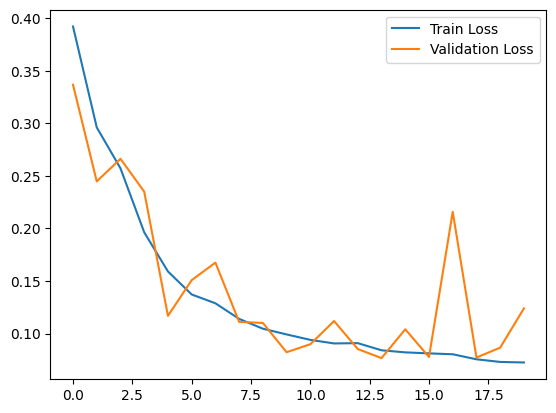

In [42]:
plt.plot(train_running_loss_history, label = 'Train Loss')
plt.plot(validation_running_loss_history, label = 'Validation Loss')
plt.legend()

In [43]:
model.eval()
X_train.size()

torch.Size([1, 1, 572, 572])

In [44]:
out = (y_pred + 0.5).int().float()

In [45]:
print(dice_index(y_train, out))
print(dice_loss(y_train, out))

tensor(0.9823, device='cuda:0')
tensor(0.0177, device='cuda:0')


IndexError: index 1 is out of bounds for dimension 0 with size 1

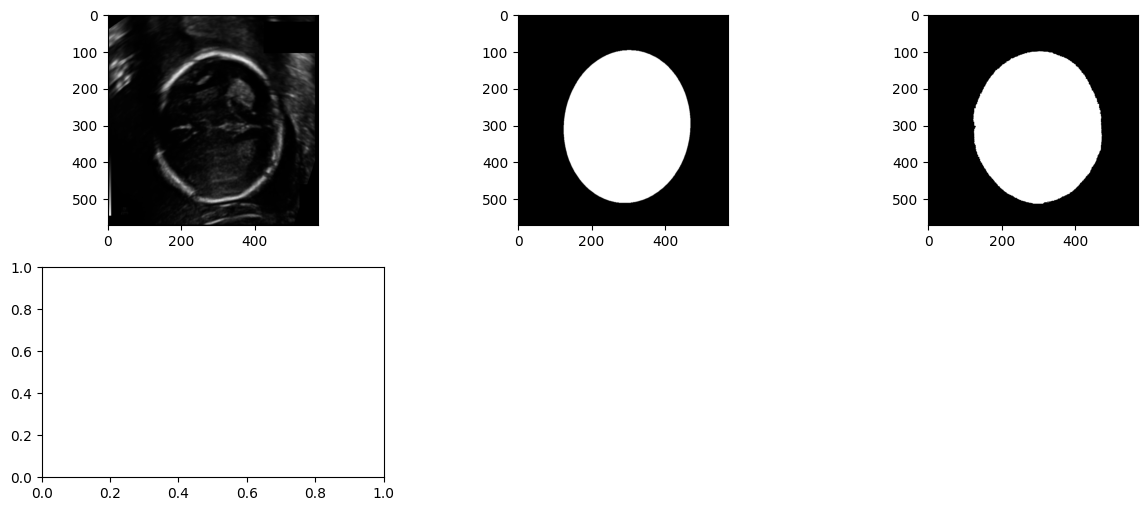

In [46]:
pig = plt.figure(figsize = (15, 6))

a = pig.add_subplot(2, 3, 1)
plt.imshow(im_converterX(X_train[0]))

a = pig.add_subplot(2, 3, 2)
plt.imshow(im_converterY(y_train[0]))

a = pig.add_subplot(2, 3, 3)
plt.imshow(im_converterY(out[0]))


a = pig.add_subplot(2, 3, 4)
plt.imshow(im_converterX(X_train[1]))

a = pig.add_subplot(2, 3, 5)
plt.imshow(im_converterY(y_train[1]))

a = pig.add_subplot(2, 3, 6)
plt.imshow(im_converterY(out[1]))

In [ ]:
gg = dice_index(out, y_train)
print(gg)
print(dice_loss(out, y_train))

tensor(0.9775, device='cuda:0')
tensor(0.0225, device='cuda:0')


In [59]:
class HC18_test(Dataset):
    def __init__(self, root_dir, transformX = None):
        self.pixel_file = pd.read_csv(os.path.join(root_dir, 'test_set_pixel_size.csv'))
        self.root_dir = root_dir
        self.transformX = transformX

    def __len__(self):
        return len(self.pixel_file)

    def __getitem__(self, index):
        imx_name = os.path.join(self.root_dir, 'test_set', self.pixel_file.iloc[index, 0])

        imx = Image.open(imx_name)

        f_name = self.pixel_file.iloc[index, 0]

        if self.transformX :
            imx = self.transformX(imx)

        sample = {'image': imx, 'f_name': f_name}
        return sample

In [48]:
test_data = HC18_test('/content/Hc_calculation', transformX = tx_X)

In [50]:
test_loader = DataLoader(dataset = test_data, batch_size = 2, shuffle = True)

0 torch.Size([2, 1, 572, 572])


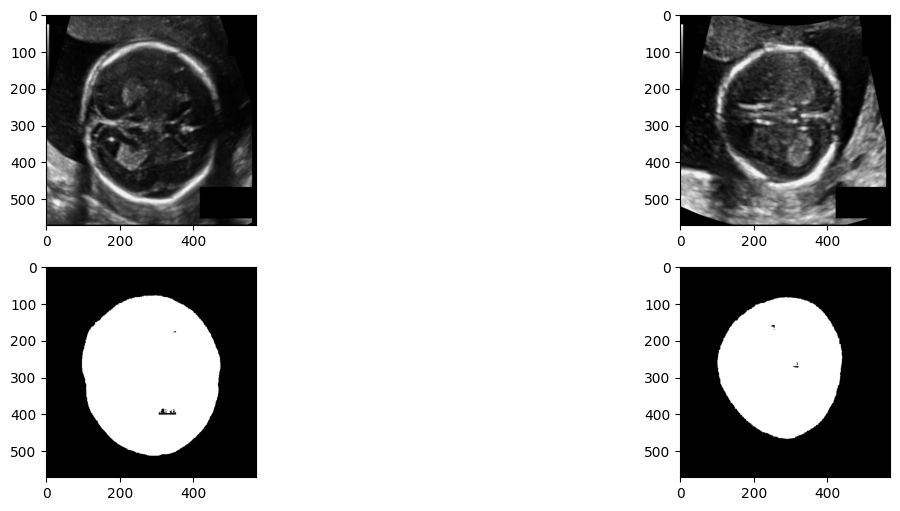

In [65]:
## Here we loop through our train_loader and see the images
## Looks good
fig = plt.figure(figsize = (15,6))
#model.to('cpu')
for ith_batch, sample_batched in enumerate(test_loader):

    X_test = sample_batched['image'].to('cuda')
    print(ith_batch, X_test.size())

    y_test = (model(X_test) + 0.5).int().float()



    for index in range(2):
        ax = fig.add_subplot(2, 2 , index + 1)  # subplot index starts from 1
        plt.imshow(im_converterX(X_test[index]))

        ax  = fig.add_subplot(2, 2, index + 3)
        plt.imshow(im_converterY(y_test[index]))
    break

In [66]:
def avg_dice_index(dataloader):

    dice = 0.0
    model.eval()
    with torch.no_grad():

        for ith_batch, sample_batched in enumerate(dataloader):

            X_train = sample_batched['image'].to('cuda')
            y_train = sample_batched['annotation'].to('cuda')

            y_predict = (model(X_train) + 0.5).int().float()

            dice += dice_index(y_predict, y_train)



    avg_dice = dice / len(dataloader)
    return avg_dice.item()

In [67]:
avg_dice_index(test_loader)    

0.9064667820930481

In [68]:
avg_dice_index(train_loader)       

0.8941748738288879

In [ ]:
test_loader = DataLoader(dataset = test_data, batch_size = 1, shuffle = True) # to write image files

## **Writting to CSV!!!**


In [77]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torchvision
from torchvision import transforms

# Define the transformation
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((540, 800)),
    transforms.ToTensor()
])

# Run inference and save segmented images
with torch.no_grad():
    # model.eval()  # Uncomment if model needs to be in evaluation mode
    for ith_batch, sample in enumerate(test_loader):
        X_test = sample['image'].to('cuda')
        y_pred = (model(X_test) + 0.5).int().float().cpu()

        file_names = sample['f_name']

        for idx in range(len(file_names)):
            teamhc = transform(y_pred[idx])
            torchvision.utils.save_image(teamhc, os.path.join('/content/segmented', file_names[idx]))

    print("Segmentation files written")

# Define the function to fit an ellipse
def fit_ellipse(im):
    imgray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        contour_sizes = [len(contour) for contour in contours]
        largest_contour = contours[np.argmax(contour_sizes)]

        if len(largest_contour) >= 5:  # Ensure there are enough points to fit an ellipse
            ellipse = cv2.fitEllipse(largest_contour)
            return ellipse
    return None

# Function to calculate ellipse circumference using Ramanujan's approximation
def ellipse_circumference(a, b):
    # Convert to mm if the input is in pixels
    h = ((a - b) ** 2) / ((a + b) ** 2)
    circumference = np.pi * (a + b) * (1 + (3 * h) / (10 + np.sqrt(4 - 3 * h)))
    return circumference

# Load pixel size data
df_pixel_size = pd.read_csv('/content/Hc_calculation/test_set_pixel_size.csv')

# Initialize submission dictionary
submission = {
    'filename': [], 'center_x_mm': [], 'center_y_mm': [], 'semi_axes_a_mm': [],
    'semi_axes_b_mm': [], 'angle_rad': [], 'circumference_mm': [], 'Index': []
}

# Process each segmented image
file_names = sorted([file for _, _, files in os.walk('/content/segmented/') for file in files])

for i, file_name in enumerate(file_names):
    im = cv2.imread('/content/segmented/' + file_name)

    if im is not None:
        ellipse = fit_ellipse(im)

        if ellipse:
            im_mask = cv2.ellipse(np.zeros_like(im), ellipse, (255, 255, 255), -1)
            image_name = file_name.split('.')[0] + '_Annotation_fit.png'
           

            pixel_size = df_pixel_size.loc[df_pixel_size['filename'] == file_name, 'pixel size(mm)'].iloc[0]
            submission['filename'].append(file_name)
            submission['Index'].append(int(file_name.split('_')[0]))

            center_x, center_y = ellipse[0]
            semi_axes_b, semi_axes_a = ellipse[1]
            angle = ellipse[2]

            # Scale axes by pixel size
            semi_axes_a_mm = semi_axes_a * pixel_size
            semi_axes_b_mm = semi_axes_b * pixel_size

            submission['center_x_mm'].append(pixel_size * center_x)
            submission['center_y_mm'].append(pixel_size * center_y)
            submission['semi_axes_a_mm'].append(semi_axes_a_mm / 2)
            submission['semi_axes_b_mm'].append(semi_axes_b_mm / 2)

            angle += 90 if angle < 90 else -90
            submission['angle_rad'].append(np.deg2rad(angle))

            # Calculate and append the circumference using Ramanujan's approximation
            circumference = ellipse_circumference(semi_axes_a_mm / 2, semi_axes_b_mm / 2)
            submission['circumference_mm'].append(circumference)

submission_df = pd.DataFrame(submission)
submission_df = submission_df[['filename', 'center_x_mm', 'center_y_mm',
                               'semi_axes_a_mm', 'semi_axes_b_mm', 'angle_rad',
                               'circumference_mm', 'Index']]
submission_df = submission_df.sort_values(['Index']).drop('Index', axis=1)
submission_df.to_csv("fetal.csv", index=False)

print('Required .csv file generated')


Segmentation files written
Required .csv file generated


In [78]:
q = pd.read_csv('/content/featl.csv')
q  ## to check theck the generated csv

,filename,center_x_mm,center_y_mm,semi_axes_a_mm,semi_axes_b_mm,angle_rad,circumference_mm
0,000_HC.png,94.087184,65.908273,54.153557,38.914078,3.103655,294.343793
1,001_HC.png,30.501383,21.326422,12.115060,10.108893,3.121151,69.960914
2,002_HC.png,60.332203,42.388131,35.528101,28.909213,0.069838,202.970123
3,003_HC.png,33.420912,28.585520,27.663191,21.892545,0.163593,156.212154
4,004_HC.png,77.321299,64.121445,55.496485,36.906842,0.176082,293.238395
...,...,...,...,...,...,...,...
330,330_HC.png,53.162674,29.829931,33.787987,26.665213,2.895823,190.579031
331,331_HC.png,24.798933,18.892105,13.433491,10.844433,2.557056,76.488356
332,332_HC.png,43.837595,31.287176,30.482121,24.233910,3.047289,172.456325
333,333_HC.png,70.334100,63.323243,33.442419,26.830549,3.064639,189.923204


In [81]:
print('Length of csv file:',len(q))

Length of csv file: 335
